# 05 — Method Comparison and Findings

Synthesizes TWFE, event-study/CS, synthetic control, and border-discontinuity estimates side by side. The sensitivity of the answer to method choice is itself the key finding in this literature — a single point estimate understates how contested the true effect is (see Card & Krueger 1994 vs. Neumark & Wascher 2000 for the canonical example of this disagreement).

In [1]:
import sys
sys.path.insert(0, r"C:\Users\thoma\minimum-wage-causal-inference")


In [2]:
import shutil
import pandas as pd

from src.data.loader import load_state_year_panel
from src.methods.twfe_did import estimate_twfe
from src.methods.border_discontinuity import border_pair_diffs, estimate_border_effect

panel, is_synthetic = load_state_year_panel()
HAS_R = shutil.which('Rscript') is not None
rows = []

In [3]:
twfe_result = estimate_twfe(panel)
ci = twfe_result.conf_int()
rows.append({
    'method': 'TWFE DiD',
    'coef': twfe_result.params['log_minimum_wage'],
    'ci_lower': ci.loc['log_minimum_wage', 'lower'],
    'ci_upper': ci.loc['log_minimum_wage', 'upper'],
})

In [4]:
states = sorted(panel.state.unique())
demo_pairs = list(zip(states[::2], states[1::2]))
diffs = border_pair_diffs(panel, demo_pairs, treatment='minimum_wage')
border_model = estimate_border_effect(diffs)
ci = border_model.conf_int()
rows.append({
    'method': 'Border discontinuity',
    'coef': border_model.params['treatment_diff'],
    'ci_lower': ci.loc['treatment_diff', 0],
    'ci_upper': ci.loc['treatment_diff', 1],
})

In [5]:
if HAS_R:
    from src.methods.r_bridge import run_callaway_santanna
    cs = run_callaway_santanna(panel)
    overall = cs[cs.group.isna()].iloc[0]
    rows.append({
        'method': "Callaway-Sant'Anna",
        'coef': overall.att, 'ci_lower': overall.ci_lower, 'ci_upper': overall.ci_upper,
    })
else:
    print("Skipping Callaway-Sant'Anna: R not available.")

Skipping Callaway-Sant'Anna: R not available.


In [6]:
comparison = pd.DataFrame(rows)
comparison

,method,coef,ci_lower,ci_upper
0,TWFE DiD,-0.094460,-0.221697,0.032777
1,Border discontinuity,0.024229,-0.165138,0.213597


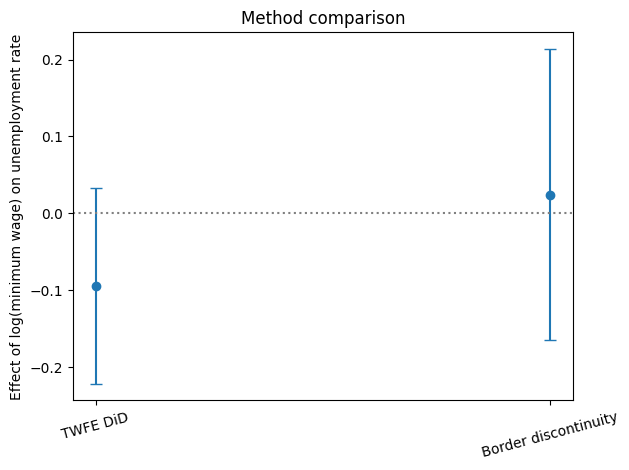

In [7]:
import matplotlib.pyplot as plt

plt.errorbar(comparison.method, comparison.coef,
             yerr=[comparison.coef - comparison.ci_lower, comparison.ci_upper - comparison.coef],
             fmt='o', capsize=4)
plt.axhline(0, color='gray', linestyle=':')
plt.ylabel('Effect of log(minimum wage) on unemployment rate')
plt.title('Method comparison'); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Interpretation

- If confidence intervals across methods overlap and straddle zero, the data don't support a strong disemployment effect at conventional significance.
- If TWFE and the border-discontinuity/CS estimates diverge, that's evidence either staggered-timing bias (TWFE vs. CS) or confounding regional shocks (TWFE vs. border-discontinuity) is affecting the naive estimate.
- On the synthetic panel (ground truth built into `src/data/synthetic.py`), these estimators should all recover roughly the same sign and order of magnitude as `TRUE_EFFECT`, which is the check to look for when swapping in real data.